# General overview

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import plotly.express as px
import ipywidgets as widgets
from IPython.display import display
import numpy as np
import seaborn as sns

## Spis treści

I. High-Level Overview (The "Big Picture")
1. Oldest/latest film.
2. Number of significant titles.
3. Chart: quantity - year.
4. Share of short films.
5. Number of films in each genre.
6. Mapping Production (Film Geopolitics).
7. Share of films based on.
8. Top 20 studios.

II. Technical Evolution & Trends
1. Chart: year/average length.
2. Seasonality of Premieres.
3. The Polish release delay.
4. Budget and revenue over the years.

III. The Business of Cinema (Money & Success)
1. The Blockbuster Threshold.
2. Return on Investment (ROI) Analysis.
3. Correlation between VOD presence and selected features.

IV. The Human Element
1. The Critic vs. Fan Divide.
2. Anticipation vs. Reality.
3. Popularity Score - Top 10 most popular films.

In [41]:
df = pd.read_csv("../database/films_data.csv")
print(f"Rekords: {df.shape[0]}")

Rekords: 732450


# I. High-Level Overview (The "Big Picture")

### 1. Oldest/latest film

In [42]:
df_clean = df.dropna(subset=["worldReleaseDate"])

In [43]:
min_year = df_clean["year"].min()
max_year = df_clean["year"].max()

min_date_idx = df_clean[df_clean["year"] == min_year]["worldReleaseDate"].idxmin()
max_date_idx = df_clean[df_clean["year"] == max_year]["worldReleaseDate"].idxmax()

oldest_film = df_clean.loc[min_date_idx ]
latest_film = df_clean.loc[max_date_idx]

In [44]:
print("The oldest film in dataset: ")
print(f"{oldest_film['originalTitle']} - {oldest_film['year']} - {oldest_film['url']}")

print("\nThe latest film in dataset: ")
print(f"{latest_film['originalTitle']} - {latest_film['year']} - {latest_film['url']}")

The oldest film in dataset: 
Passage de Venus - 1888 - https://www.filmweb.pl/film/Passage+de+Venus-1888-701519

The latest film in dataset: 
Avatar 5 - 2031 - https://www.filmweb.pl/film/Avatar+5-2031-771820


### 2. Number of significant titles
In this section, assessing whether a film is significant consists of checking if the film has any description.

In [45]:
df_significant = df[(df["desc_short"].notna() | df["desc_long"].notna()) & (df["rate_count"] != 0)].copy()
df_less_significant = df[(df["desc_short"].isna() & df["desc_long"].isna()) & (df["rate_count"] != 0)].copy()
df_not_significant = df[df["rate_count"] == 0].copy()


size_significant = df_significant.shape[0]
size_less_significant = df_less_significant.shape[0]
size_not_significant = df_not_significant.shape[0]

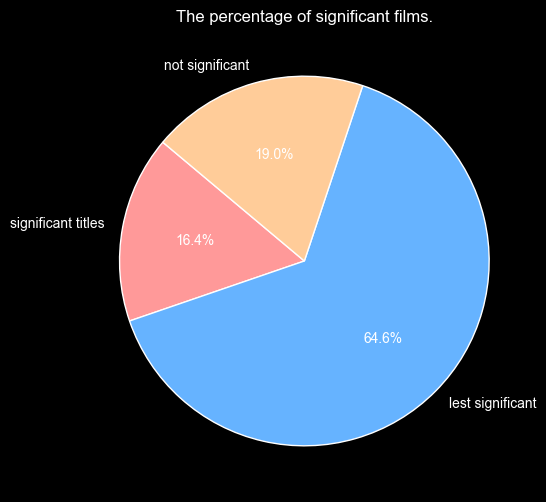

In [46]:
labels = ['significant titles', 'less significant', "not significant"]
values = [size_significant, size_less_significant, size_not_significant]
colors = ['#ff9999', '#66b3ff', '#ffcc99']

plt.figure(figsize=(6, 6))
plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors)

plt.title('The percentage of significant films.')
plt.show()

Legend:
- Significant titles – Films with both a description and a score.
- Less significant – Films with a score, but lacking a description.
- Not significant – Films with neither a description nor a score.

As shown in the chart, only ~16.4% of films gain greater popularity and can be considered significant.

### 2.1 Checking the median number of ratings for each category.

In [47]:
important_median_rates = df_significant["rate_count"].median()
rest_median_rates = df_less_significant["rate_count"].median()

print(f"Mean rate count for significant films: {important_median_rates:.1f}, less significant: {rest_median_rates:.1f}")

Mean rate count for significant films: 57.0, less significant: 2.0


### 3. Chart: quantity - year

In [48]:
year_count = df["year"].value_counts()
year_count_sorted = year_count.sort_index()

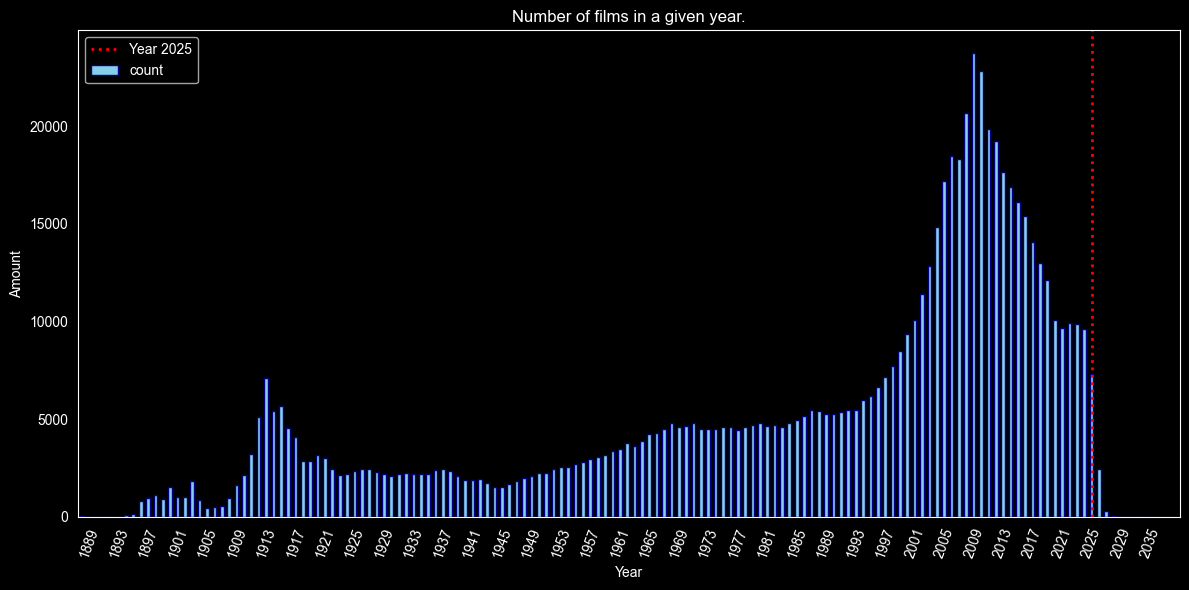

In [49]:
plt.figure(figsize=(12, 6))
year_count_sorted.plot(kind='bar', color='skyblue', edgecolor='navy')

plt.title('Number of films in a given year.')
plt.xlabel('Year')
plt.ylabel('Amount')
plt.xticks(list(range(1, 150, 4)), rotation=70)
plt.grid(False)

pos_2025 = year_count_sorted.index.get_loc(2025)
plt.axvline(x=pos_2025, color='red', linestyle=':', linewidth=2, label='Year 2025')
plt.legend()

plt.tight_layout()
plt.show()

We see a gradual increase in the number of films per year until the chart peaks in 2009 at ~24,000 films. Then, we see a sharp downward
trend. The possible cause of such a sudden increase in the years 1995–2018 will be explained in the following section.

### 4. Share of short films (pl. Krótkometrażowy)

In [50]:
df['Type'] = df['genres'].str.contains('Krótkometrażowy', na=False, case=False)
df['Type'] = df['Type'].map({True: 'Krótkometrażowy', False: 'Pozostałe'})

df_total = df['Type'].value_counts().reset_index()
df_total.columns = ['Type', 'count']

df_counts = df.groupby(['year', 'Type']).size().reset_index(name='count')

In [51]:
fig_static = px.pie(df_total,
                    values='count',
                    names='Type',
                    title="Total share (all years)",
                    hole=0.4,
                    color='Type',
                    color_discrete_map={'Krótkometrażowy': '#EF553B', 'Rest': '#636EFA'})

fig_static.update_layout(margin=dict(l=20, r=20, t=50, b=20))

def show_dual_charts(rok):
    data_year = df_counts[df_counts['year'] == rok]

    fig_dynamic = px.pie(data_year,
                         values='count',
                         names='Type',
                         title=f"Yearly share {rok}",
                         hole=0.4,
                         color='Type',
                         color_discrete_map={'Krótkometrażowy': '#EF553B', 'Rest': '#636EFA'})
    fig_dynamic.update_layout(margin=dict(l=20, r=20, t=50, b=20))

    out1 = widgets.Output()
    out2 = widgets.Output()

    with out1:
        fig_static.show()
    with out2:
        fig_dynamic.show()

    layout = widgets.HBox([out2, out1])
    display(layout)

# Triggering interaction.
widgets.interact(show_dual_charts, rok=widgets.IntSlider(
    value=2025,
    min=df['year'].min(),
    max=df['year'].max(),
    step=1,
    description='Rok:'))

interactive(children=(IntSlider(value=2025, description='Rok:', max=2035, min=1888), Output()), _dom_classes=(…

<function __main__.show_dual_charts(rok)>

#### 4.1 Share of short films over the years

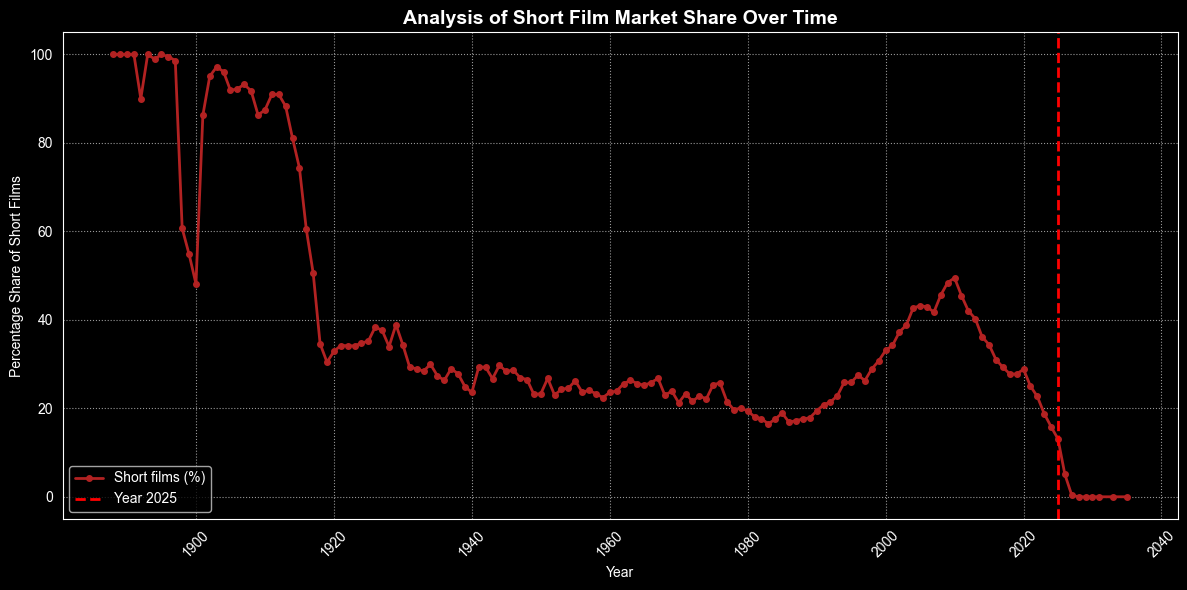

In [52]:
import matplotlib.pyplot as plt

yearly_stats = df.groupby(['year', 'Type']).size().unstack(fill_value=0)
yearly_stats['total'] = yearly_stats.sum(axis=1)
yearly_stats['pct_short'] = (yearly_stats['Krótkometrażowy'] / yearly_stats['total']) * 100

plt.figure(figsize=(12, 6))

plt.plot(yearly_stats.index, yearly_stats['pct_short'],
         color='firebrick', marker='o', markersize=4, linestyle='-', linewidth=2, label='Short films (%)')

plt.axvline(x=2025, color='red', linestyle='--', linewidth=2, label='Year 2025')

plt.title('Analysis of Short Film Market Share Over Time', fontsize=14, fontweight='bold')
plt.ylabel('Percentage Share of Short Films', fontsize=10)
plt.xlabel('Year', fontsize=10)

plt.grid(True, linestyle=':', alpha=0.6)
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

The chart shows that short films dominated the early years of the cinema era. Between 1920 and 1990, feature-length films became more
prevalent and gained significance year by year. A drastic shift in the trend occurred between 1990 and 2010, when short-format films made
 a comeback. Finally, from 2010 onwards, feature-length films began taking over the market—a trend that continues to this day, with short
  films reaching a minimum of 13.2%.

Such a large number of short films (which are much easier to produce) is likely the reason for the significant increase in the number of films between 1995 and 2018.

### 5. Number of films in each genre
When analyzing film genres, keep in mind that each film can have more than one genre.

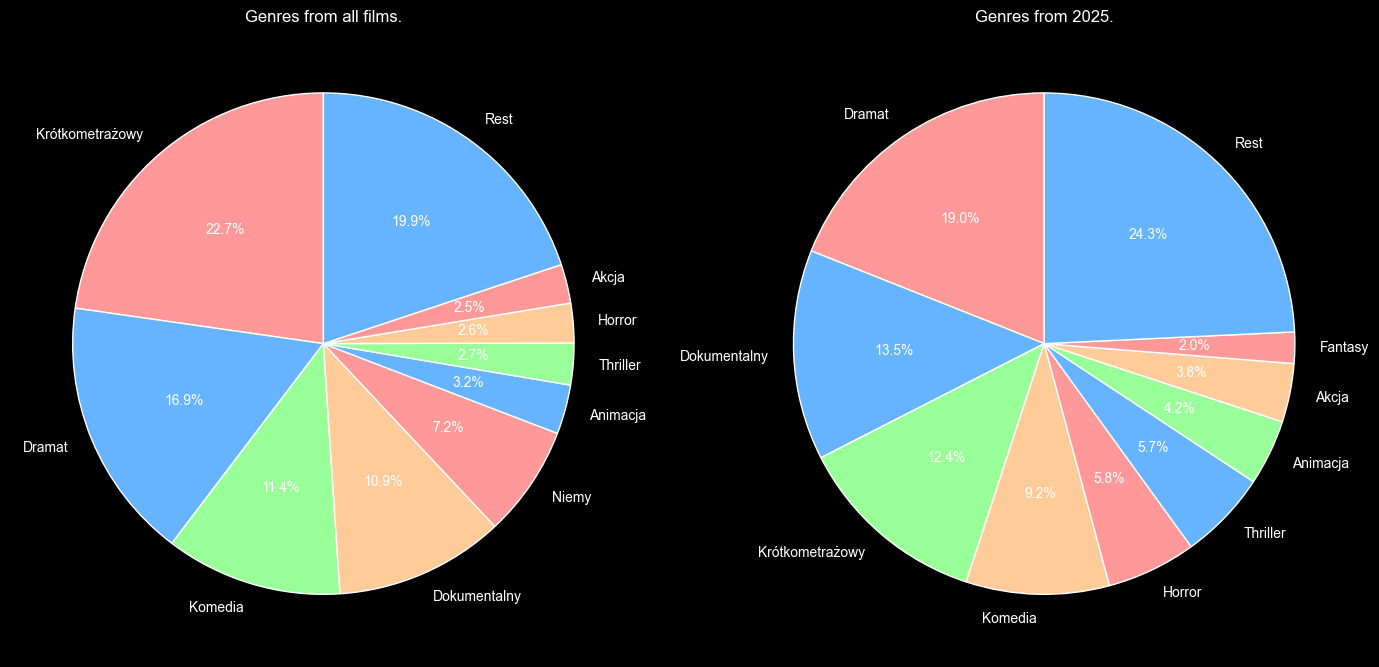

In [53]:
def get_top5_and_rest(df, top_x=9):
    df_dummies = df['genres'].str.get_dummies(sep=', ')
    s_sorted = df_dummies.sum().sort_values(ascending=False)
    top5 = s_sorted.iloc[:top_x]
    rest = pd.Series({'Rest': s_sorted.iloc[top_x:].sum()})
    return pd.concat([top5, rest])


genre_series_all = get_top5_and_rest(df)
genre_series_year = get_top5_and_rest(df[df['year'] == 2025])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

# Left figure
genre_series_all.plot.pie(
    ax=ax1,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#ff9999', '#66b3ff', '#99ff99', '#ffcc99']
)
ax1.set_title("Genres from all films.")
ax1.set_ylabel('')

# Right figure
genre_series_year.plot.pie(
    ax=ax2,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#ff9999', '#66b3ff', '#99ff99', '#ffcc99']
)
ax2.set_title("Genres from 2025.")
ax2.set_ylabel('')


plt.tight_layout()
plt.show()

An overview of the top 5 most popular genres overall and in 2025. A broader shift in trends is shown in the next chart.

#### 5.1 Evolution of film genres over time.

In [54]:
df_genres = df['genres'].str.get_dummies(sep=', ')
df_genres['year'] = df['year']
yearly_genres = df_genres.groupby('year').sum()

In [55]:
top_genres = yearly_genres.sum().sort_values(ascending=False).head(9).index
plot_data = yearly_genres[top_genres].copy()
plot_data['Rest'] = yearly_genres.drop(columns=top_genres).sum(axis=1)

In [56]:
plot_data_pct = plot_data.div(plot_data.sum(axis=1), axis=0) * 100

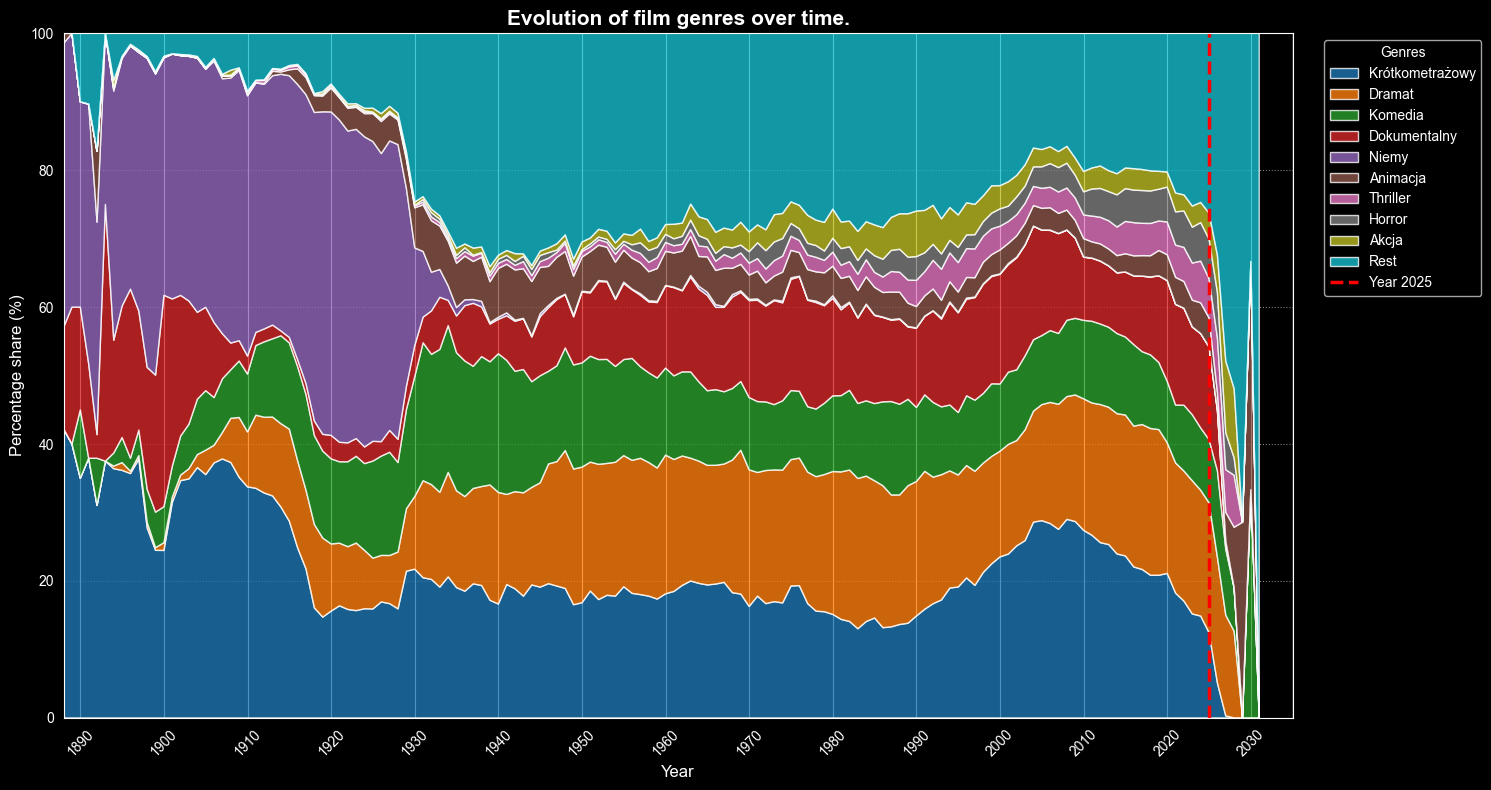

In [57]:
plt.figure(figsize=(15, 8))

plt.stackplot(plot_data_pct.index,
              [plot_data_pct[col] for col in plot_data_pct.columns],
              labels=plot_data_pct.columns,
              alpha=0.8,
              colors=plt.cm.tab10.colors)

plt.axvline(x=2025, color='red', linestyle='--', linewidth=2.5, label='Year 2025')

plt.title('Evolution of film genres over time.', fontsize=15, fontweight='bold')
plt.ylabel('Percentage share (%)', fontsize=12)
plt.xlabel('Year', fontsize=12)

plt.xlim(plot_data_pct.index.min(), plot_data_pct.index.max())
plt.ylim(0, 100)
plt.grid(axis='y', linestyle=':', alpha=0.5)

plt.legend(title='Genres', bbox_to_anchor=(1.02, 1), loc='upper left')

years = np.arange(1890, plot_data_pct.index.max() + 1, 10)
plt.xticks(years, rotation=45)

plt.tight_layout()
plt.show()

The chart reveals four distinct periods:
1. 1888–1930: The Silent Era. Dominated by short and silent films.
2. 1930–2000: Diverse Cinema. New genres such as action, horror, and thriller emerge in the top 9.
3. 2000–2025: Modern Cinema. Consolidation of existing genres. The top 9 genres strengthen their position, while others see a decline.
4. 2025–2035: Upcoming films. Notably, it is mainly animated films that are assigned distant release dates.

### 6. Mapping Production (Film Geopolitics)

In [58]:
one_hot = df['production_country'].str.get_dummies(sep=', ')

In [59]:
s_all_countries = one_hot.sum()
total_occurrences = s_all_countries.sum()

top_30 = s_all_countries.sort_values(ascending=False).head(30)

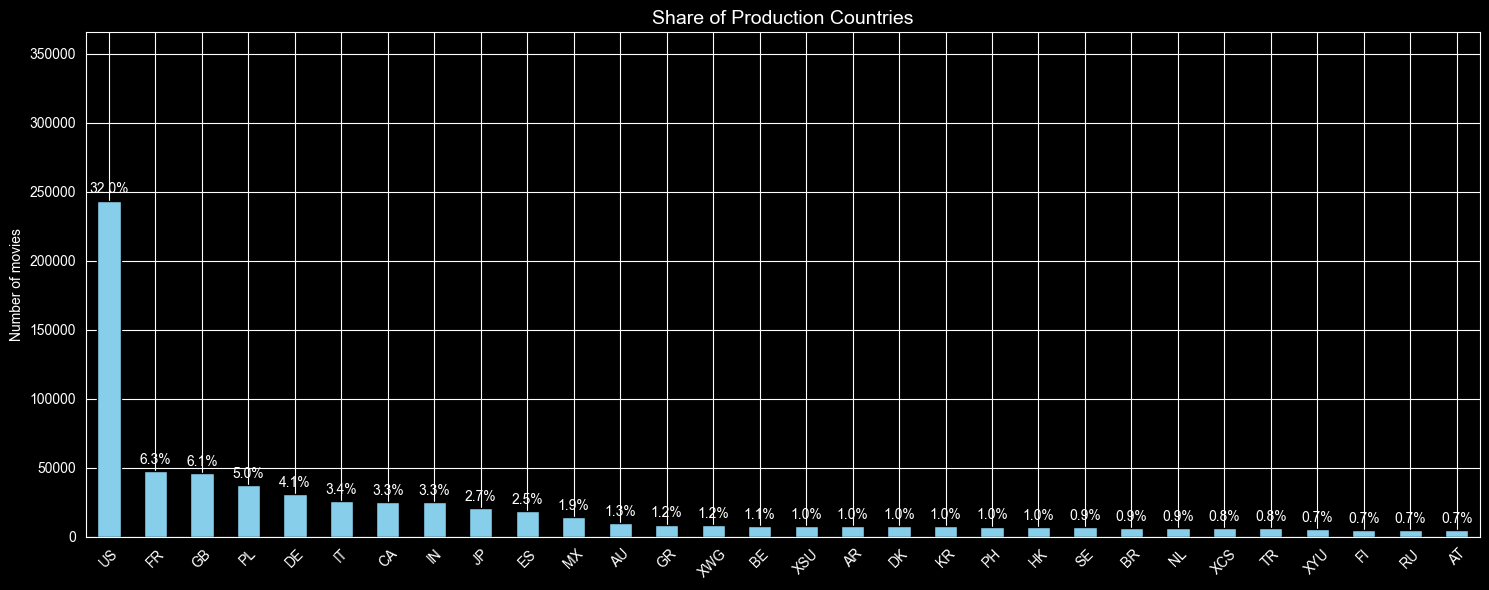

In [60]:
ax = top_30.plot.bar(figsize=(15, 6), color='skyblue', edgecolor='black')

percentages = [f'{(val / total_occurrences * 100):.1f}%' for val in top_30]

ax.bar_label(ax.containers[0], labels=percentages, padding=3, fontsize=10)

plt.title("Share of Production Countries", fontsize=14)
plt.ylabel("Number of movies")
plt.xticks(rotation=45)
plt.ylim(0, top_30.max() * 1.5)

plt.tight_layout()
plt.show()

### 6.1 Correlation analysis by country.

In [61]:
df_clean = df.dropna(subset=['duration', 'rate', 'rate_count', 'critic_rate',
                             'critic_count', 'budget', 'boxoffice_world', "production_country"], how="any").copy()
print(f"Before: {df.shape[0]} -> After: {df_clean.shape[0]}")

Before: 732450 -> After: 4422


In [62]:
one_hot = df_clean['production_country'].str.get_dummies(sep=', ').astype(int)

cols_x = ['duration', 'rate', 'rate_count', 'critic_rate',
          'critic_count', 'budget', 'boxoffice_world']
cols_y = one_hot.columns

In [63]:
df_temp = pd.concat([df_clean[cols_x], one_hot], axis=1)
corr_matrix = df_temp.corr().loc[cols_y, cols_x]

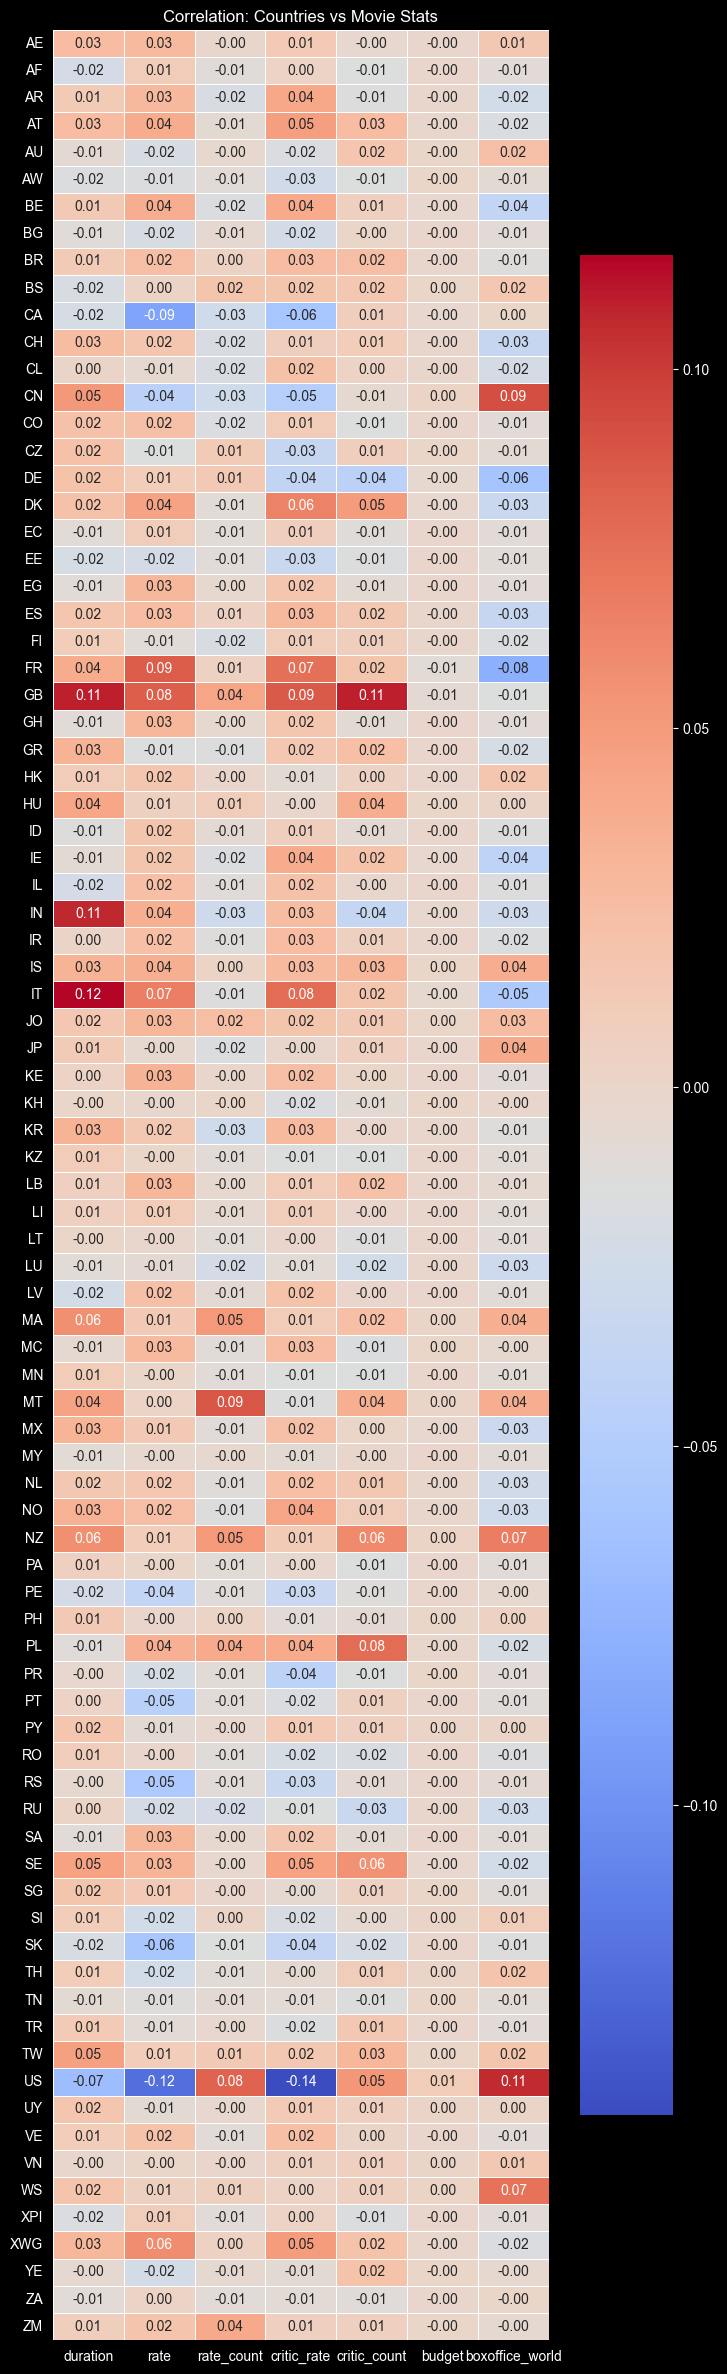

In [64]:
plt.figure(figsize=(8, 30))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.grid(False)

plt.title("Correlation: Countries vs Movie Stats")
plt.show()

No significant correlation is observed for any of the countries. This may be due to the fact that only 4,422 films meet the criteria
required to be included in this correlation.

### 7. Share of films based on.


In [65]:
films_not_based_on = df["based_on"].isna().sum()

In [66]:
films_not_based_on_amount = films_not_based_on
films_not_based_amount = df.shape[0] - films_not_based_on_amount

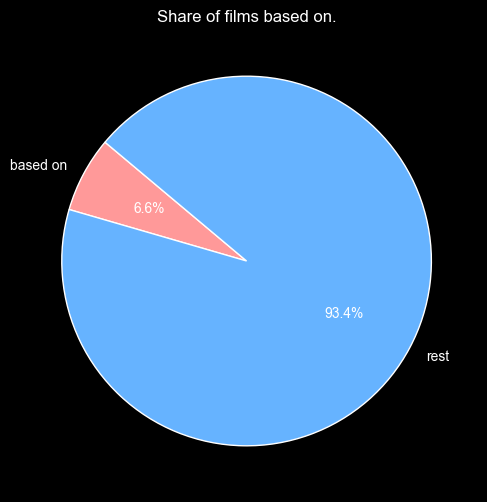

In [67]:
labels = ['based on', 'rest']
values = [films_not_based_amount, films_not_based_on_amount ]
colors = ['#ff9999', '#66b3ff']

plt.figure(figsize=(6, 6))
plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors)

plt.title('Share of films based on.')
plt.show()

## 8. Top 20 studios

This section presents the 20 studios that appear most frequently in the dataset.
It is important to note that many films are collaborative efforts involving multiple studios. While the dataset lists these studios together, their actual impact or level of contribution to a specific film may vary.

In [68]:
s_sorted = (
    df['studio']
    .str.split(r'\s*/\s*', regex=True)
    .explode()
    .value_counts()
)

s_sorted.head(20)

studio
Państwowa Wyższa Szkoła Filmowa, Telewizyjna i Teatralna (PWSFTviT)    3936
Polski Instytut Sztuki Filmowej                                        3815
Warner Bros.                                                           2626
Telewizja Polska                                                       2508
Canal+                                                                 2410
Wytwórnia Filmów Oświatowych                                           2346
Metro-Goldwyn-Mayer (MGM)                                              2330
Columbia Pictures Corporation                                          2193
Centre National de la Cinématographie (CNC)                            2131
Universal Pictures                                                     2041
Paramount Pictures                                                     1968
Wytwórnia Filmów Dokumentalnych (WFD)                                  1339
British Broadcasting Corporation (BBC)                                 1148
Mosfi

## II. Technical Evolution & Trends

### 1. Chart: year/average length

In [69]:
df_clean = df.dropna(subset=['year', "duration"], how='any')
print(f"Before: {df.shape[0]} -> After: {df_clean.shape[0]}")

Before: 732450 -> After: 511639


In [70]:
year_duration = df_clean[["year", "duration"]].groupby(by="year").median()

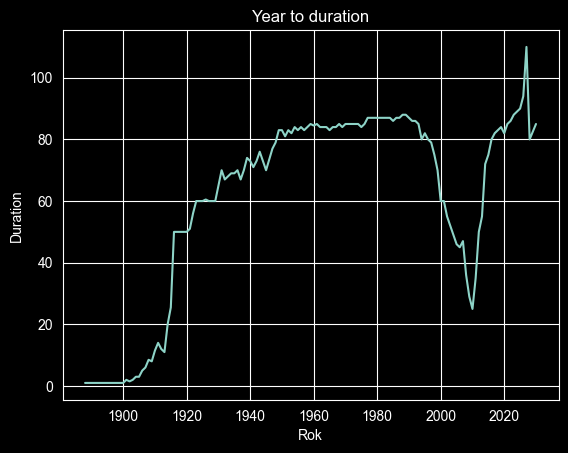

In [71]:
plt.plot(year_duration.index, year_duration["duration"].values)

plt.title("Year to duration")
plt.xlabel('Rok')
plt.ylabel('Duration')

plt.show()

Once again, between 1990 and 2015, we see the impact of the number of short films on the median film length.

### 2. Seasonality of Premieres


In [72]:
df_clean = df.dropna(subset=["worldPublicReleaseDate"]).copy()
print(f"Before: {df.shape[0]} -> After: {df_clean.shape[0]}")

Before: 732450 -> After: 381955


In [73]:
df_clean.loc[:, "month"] = df_clean["worldPublicReleaseDate"].astype("str").str[4:6]
df_clean.loc[:, "month"] = pd.to_numeric(df_clean.loc[:, "month"], errors='coerce').astype("Int64")
df_filtered = df_clean[df_clean.loc[:, "month"].between(1, 12)]

In [74]:
s_month = df_filtered[["month", "rate"]].groupby(by="month").count()

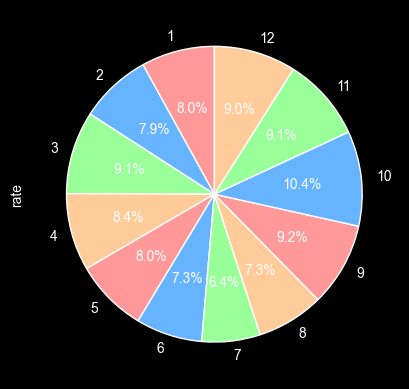

In [75]:
s_month.plot.pie(
    y="rate",
    autopct='%1.1f%%',
    startangle=90,
    colors=['#ff9999', '#66b3ff', '#99ff99', '#ffcc99'],
    legend=False
)

plt.show()

Film premieres are distributed fairly evenly.

#### 2.1 Correlation of months with selected features.

In [76]:
cols_x = ["month"]
cols_y = ["duration", "rate", "rate_count", "critic_rate", "countWantToSee","budget", "boxoffice_world"]

df_clean = df_clean.dropna(subset=cols_x + cols_y, how="any")
print(f"Before: {df.shape[0]} -> After: {df_clean.shape[0]}")

Before: 732450 -> After: 4420


In [77]:
corr_matrix = df_clean[cols_x + cols_y].corr().loc[cols_y, cols_x]

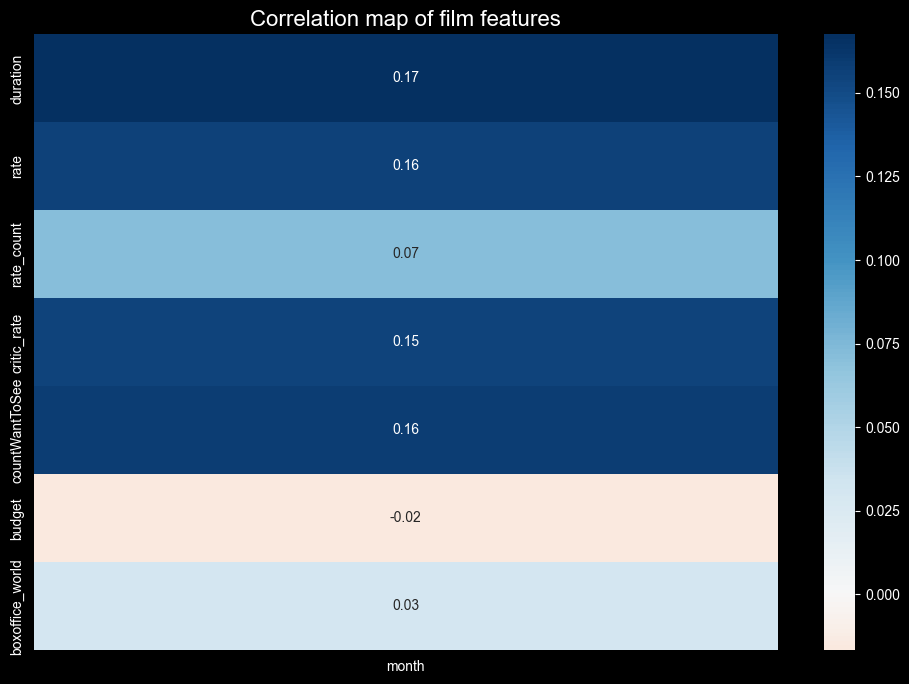

In [78]:
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu', fmt=".2f", center=0)

plt.title('Correlation map of film features', fontsize=16)
plt.show()

As shown in the chart above, the release month has no significant impact on its success.

### 3. The Polish release delay

In [79]:
df_clean["worldPublicReleaseDate"] = pd.to_datetime(df["worldPublicReleaseDate"], format='%Y%m%d', errors='coerce')
df_clean["releaseDatePoland"] = pd.to_datetime(df["releaseDatePoland"], format='%Y%m%d', errors='coerce')

In [80]:
df_clean = df_clean.dropna(subset=["worldPublicReleaseDate", "releaseDatePoland"], how="any").copy()
print(f"Before: {df.shape[0]} -> After: {df_clean.shape[0]}")

Before: 732450 -> After: 3309


In [81]:
df_clean["release_diff_days"] = (df_clean["releaseDatePoland"] - df_clean["worldPublicReleaseDate"]).dt.days

In [82]:
print(f"Median wait time in Poland: {df_clean['release_diff_days'].median():.1f} dni")

film_id = df_clean['release_diff_days'].idxmax()
film = df_clean.loc[film_id]
print(f"The longest waiting: {film['release_diff_days']} dni - {film['originalTitle']}, {film['year']} -> {film['releaseDatePoland'].year}")

Median wait time in Poland: 63.0 dni
The longest waiting: 27618 dni - The Wizard of Oz, 1939 -> 2015


### 6. Budget and revenue over the years.

In [83]:
df_clean = df.dropna(subset=["year", "budget","boxoffice_world"], how="any")
print(f"Before: {df.shape[0]} -> After: {df_clean.shape[0]}")

Before: 732450 -> After: 4818


In [84]:
s_mean_budget = df_clean.groupby("year")["budget"].median()
s_mean_boxoffice = df_clean.groupby("year")["boxoffice_world"].median()

In [85]:
s_counts = df_clean.groupby("year")["boxoffice_world"].count()
s_filter = s_counts > 15

s_mean_budget = s_mean_budget[s_filter]
s_mean_boxoffice = s_mean_boxoffice[s_filter]

In [86]:
s_mean_budget = s_mean_budget.dropna()
s_mean_boxoffice = s_mean_boxoffice.dropna()

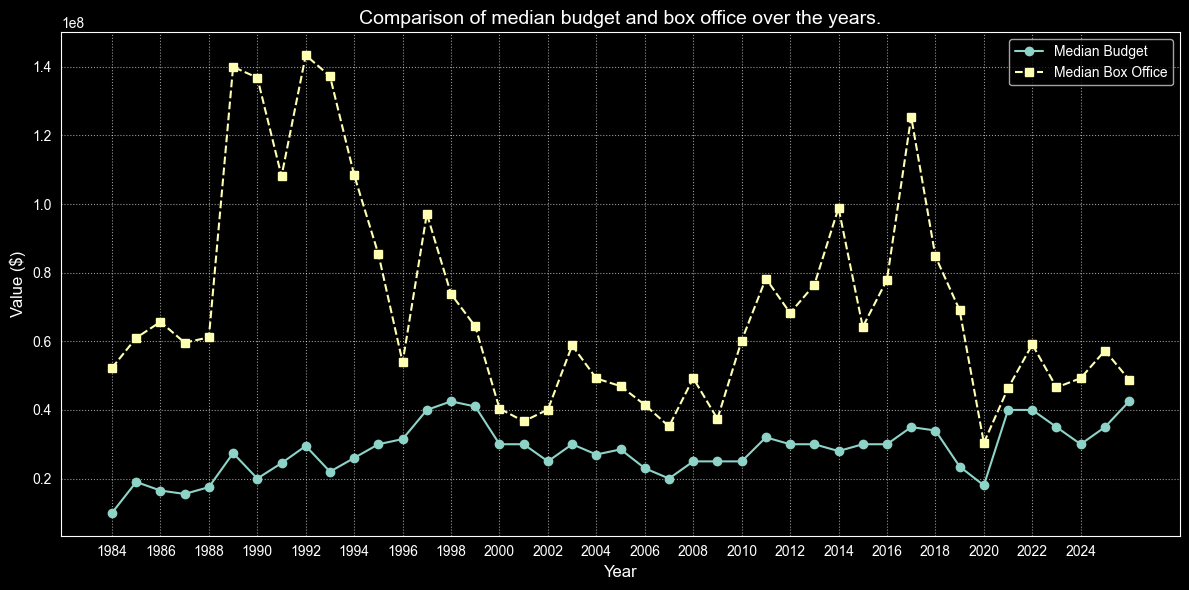

In [87]:
years = s_mean_boxoffice.index

plt.figure(figsize=(12, 6))

plt.plot(years, s_mean_budget, label='Median Budget', marker='o', linestyle='-')
plt.plot(years, s_mean_boxoffice, label='Median Box Office', marker='s', linestyle='--')

plt.title('Comparison of median budget and box office over the years.', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Value ($)', fontsize=12)

plt.xticks(list(range(min(years), max(years), 2)))

plt.legend()

plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

The sudden spike between 1988 and 1996 is primarily caused by a lack of comprehensive data for films from that period. On average, only 15–30 films per year have documented budget and revenue figures, and these are predominantly major blockbuster releases.

#### 6.1 Top 10 Highest-Grossing Films of All Time

In [88]:
df_clean.sort_values(by="boxoffice_world", ascending=False).head(10)[["originalTitle", "year","budget","boxoffice_world"]]

,originalTitle,year,budget,boxoffice_world
160279,Avatar,2009,237000000.0,2.923706e+09
565965,Avengers: Endgame,2019,356000000.0,2.799439e+09
386708,Avatar: The Way of Water,2022,250000000.0,2.343477e+09
188,Titanic,1997,200000000.0,2.264743e+09
671814,Nezha: Mo tong nao hai,2025,80000000.0,2.150000e+09
476316,Star Wars: Episode VII - The Force Awakens,2015,245000000.0,2.071310e+09
609629,Spider-Man: No Way Home,2021,200000000.0,1.921847e+09
663422,Zootopia 2,2025,150000000.0,1.866648e+09
643807,Inside Out 2,2024,200000000.0,1.698864e+09
385603,Jurassic World,2015,150000000.0,1.671537e+09


#### 6.2 Top 10 Most Expensive Movies of All Time

In [89]:
df_clean.sort_values(by="budget", ascending=False).head(10)[["originalTitle", "year","budget","boxoffice_world"]]

,originalTitle,year,budget,boxoffice_world
664195,The Bride!,2026,8.000000e+10,2.344402e+07
597071,Mission: Impossible - The Final Reckoning,2025,4.000000e+08,5.987671e+08
426931,Avatar: Fire and Ash,2025,4.000000e+08,1.485830e+09
565965,Avengers: Endgame,2019,3.560000e+08,2.799439e+09
548194,Fast X,2023,3.400000e+08,7.047097e+08
476311,Star Wars: The Last Jedi,2017,3.170000e+08,1.334408e+09
273315,Justice League,2017,3.000000e+08,6.579270e+08
45990,Pirates of the Caribbean: At World's End,2007,3.000000e+08,9.609965e+08
362373,Indiana Jones and the Dial of Destiny,2023,2.947000e+08,3.839631e+08
597041,Mission: Impossible - Dead Reckoning - Part One,2023,2.900000e+08,5.711254e+08


## III. The Business of Cinema (Money & Success)

### 1. The Blockbuster Threshold

In [90]:
df_clean = df.dropna(subset=["boxoffice_world"]).copy()
print(f"Before: {df.shape[0]} -> After: {df_clean.shape[0]}")

Before: 732450 -> After: 10190


In [91]:
df_clean["budget_category"] = df_clean["boxoffice_world"].apply(
    lambda x: "Indie" if x < 1_000_000
    else ("Mid-budget" if 1_000_000 <= x <= 50_000_000
    else ("Blockbuster" if x > 100_000_000 else "High-mid budget"))
)

In [92]:
dominating_group = df_clean["budget_category"].value_counts()
print(f"The largest group is: {dominating_group.idxmax()}")

The largest group is: Mid-budget


In [93]:
category_info = {
    "Indie": {"color": "#3498db", "label": "Indie (< $1M)"},
    "Mid-budget": {"color": "#f39c12", "label": "Mid-budget ($1M - $50M)"},
    "High-mid budget": {"color": "#2ecc71", "label": "High-mid ($50M - $100M)"},
    "Blockbuster": {"color": "#e74c3c", "label": "Blockbuster (> $100M)"}
}

plot_colors = [category_info[cat]["color"] for cat in dominating_group.index]

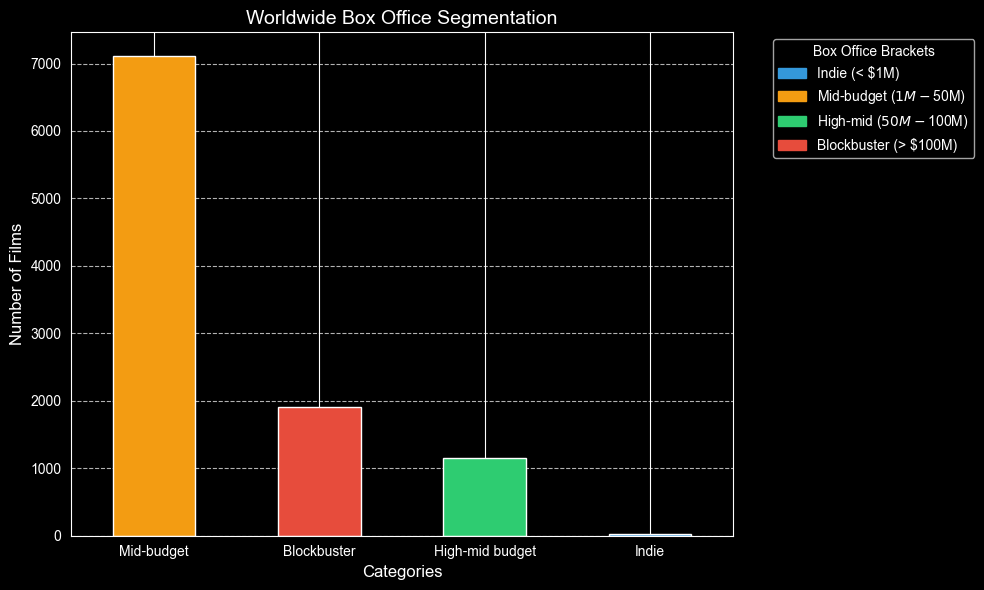

In [94]:
plt.figure(figsize=(10, 6))
ax = dominating_group.plot.bar(color=plot_colors, rot=0)

legend_handles = [
    mpatches.Patch(color=info["color"], label=info["label"])
    for info in category_info.values()
]

plt.legend(
    handles=legend_handles,
    title="Box Office Brackets",
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.title("Worldwide Box Office Segmentation", fontsize=14)
plt.xlabel("Categories", fontsize=12)
plt.ylabel("Number of Films", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### 2. Return on Investment (ROI) Analysis

In [95]:
df_with_budget = df.dropna(subset=["boxoffice_world", "budget"], how='any').copy()
print(f"Before: {df.shape[0]} -> After: {df_with_budget.shape[0]}")

Before: 732450 -> After: 4818


In [96]:
df_with_budget["investment_return (%)"] = (df_with_budget["boxoffice_world"] - df_with_budget["budget"])/df_with_budget["budget"] * 100
df_with_budget["investment_return (%)"] = df_with_budget["investment_return (%)"].round(2)

df_with_budget.sort_values("investment_return (%)", ascending=False, inplace=True)

In [97]:
df_with_budget[["originalTitle", "year", "budget", "boxoffice_world", "investment_return (%)"]].head(10)

,originalTitle,year,budget,boxoffice_world,investment_return (%)
316026,Paranormal Activity,2007,15000.0,193355800.0,1288938.67
539,The Blair Witch Project,1999,60000.0,248639099.0,414298.50
469341,The Gallows,2015,100000.0,42664410.0,42564.41
40620,Super Size Me,2004,65000.0,20641054.0,31655.47
9161,El Mariachi,1992,7000.0,2041928.0,29070.40
9196,Night of the Living Dead,1968,114000.0,30000000.0,26215.79
302339,The Stewardesses,1969,100000.0,25000000.0,24900.00
10611,Fritz the Cat,1972,850000.0,190000000.0,22252.94
3470,Halloween,1978,325000.0,60000000.0,18361.54
1503,American Graffiti,1973,777000.0,140000000.0,17918.02


In [98]:
df_with_budget[["originalTitle", "year", "budget", "boxoffice_world", "investment_return (%)"]].tail(10)

,originalTitle,year,budget,boxoffice_world,investment_return (%)
126374,Seraphim Falls,2006,1.800000e+07,1220058.0,-93.22
529574,Bilal: A New Breed of Hero,2016,3.000000e+07,1902602.0,-93.66
429540,Stolen,2012,3.500000e+07,2106557.0,-93.98
381231,Lay the Favorite,2012,2.635000e+07,1576687.0,-94.02
672550,Kiss of the Spider Woman,2025,3.000000e+07,1692747.0,-94.36
510388,The King's Daughter,2022,4.050000e+07,2231447.0,-94.49
646096,Eden,2024,5.500000e+07,2811540.0,-94.89
583186,The Tax Collector,2020,3.000000e+07,1325781.0,-95.58
99,Lolita,1997,6.200000e+07,1953255.0,-96.85
664195,The Bride!,2026,8.000000e+10,23444025.0,-99.97


#### 2.1 Percentage of Profitable Films

In [99]:
films_with_returned_invest = df_with_budget[df_with_budget["investment_return (%)"] > 0]

In [100]:
plus = films_with_returned_invest.shape[0]
minus = df_with_budget.shape[0] - films_with_returned_invest.shape[0]

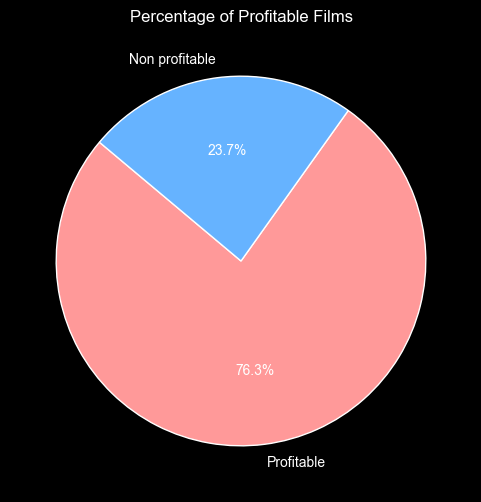

In [101]:
labels = ['Profitable', 'Non profitable']
values = [plus, minus]
colors = ['#ff9999', '#66b3ff']

plt.figure(figsize=(6, 6))
plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors)

plt.title('Percentage of Profitable Films')
plt.show()

### 3. Correlation between VOD presence and selected features.

In [102]:
cols_x = [ "rate", "rate_count", "critic_rate", "critic_count", "boxoffice_world", "budget"]
df_clean = df.dropna(subset=cols_x, how="any")
print(f"Before: {df.shape[0]} -> After: {df_clean.shape[0]}")

Before: 732450 -> After: 4422


In [103]:
df_vod_dummies = df_clean["vod"].str.get_dummies(sep=', ')

In [104]:
df_temp = pd.concat([df_clean[cols_x], df_vod_dummies], axis=1)
df_temp["isVod"] = df_clean["vod"].notna()

In [105]:
cols_y = df_vod_dummies.columns.values.tolist() + ["isVod"]

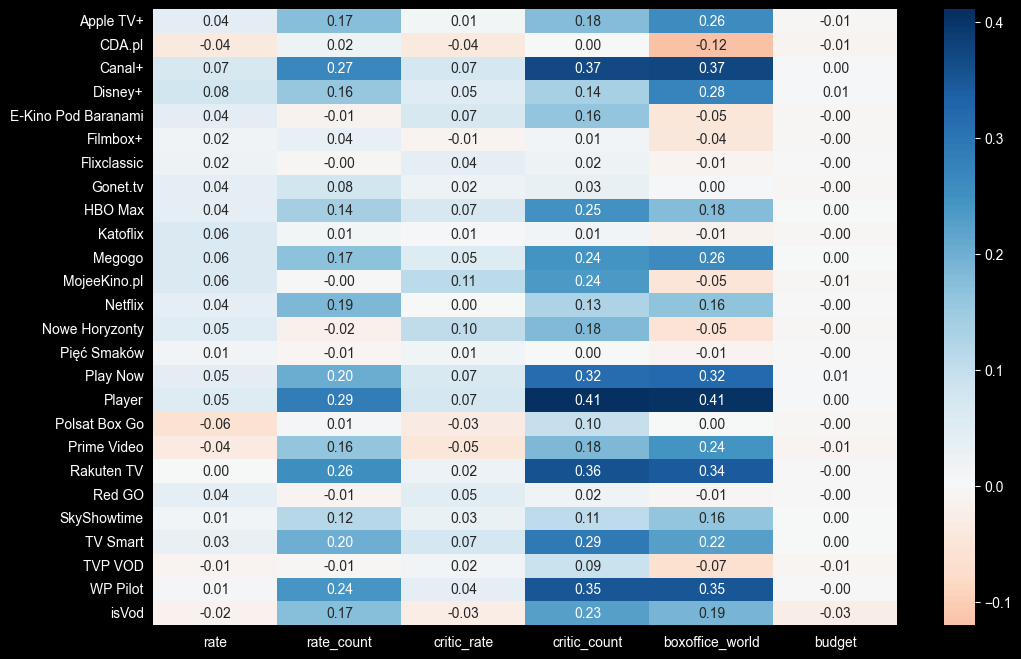

In [106]:
corr_matrix = df_temp.corr().loc[cols_y, cols_x]

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu', fmt=".2f", center=0)

plt.title('', fontsize=16)
plt.show()

No significant correlations are observed between a film's presence on VOD platforms and the selected variables. However, a positive
influence from platforms such as Canal+, Play Now, Player, and WP Pilot is visible regarding the number of critic reviews and global box
office performance.

The presence of films on Polish platforms (WP Pilot, Play Now, Player) may indeed impact the number of critic reviews, as many of the reviewers are based in Poland. However, without further, more in-depth analysis, it is difficult to explain the correlation between these specific platforms and global box office results.

There is one more reason why these platforms show both high **critic_score** and **boxoffice_world** results. It is possible that these platforms only stream films that have already achieved success. In this case, it is unlikely that these high scores are caused by the film's presence on the platform, but rather the other way around.

## V. The Human Element

### 1. The Critic vs. Fan Divide

#### 1.1 Ratings Comparison

In [107]:
df_clean = df.dropna(subset=["rate", "critic_rate"], how="any")
print(f"Before: {df.shape[0]} -> After: {df_clean.shape[0]}")

Before: 732450 -> After: 40092


In [108]:
change = (df_clean["rate"] - df_clean["critic_rate"]).abs().median()

In [109]:
print(f"Median Rating Gap Between Users and Critics: {change:.2f}")

Median Rating Gap Between Users and Critics: 0.72


#### 1.2 Number of Ratings Comparison

In [110]:
df_clean = df.dropna(subset=["rate_count", "critic_count"], how="any").copy()
print(f"Before: {df.shape[0]} -> After: {df_clean.shape[0]}")

Before: 732450 -> After: 40092


In [111]:
total_reviews = df_clean["rate_count"] + df_clean["critic_count"]
df_clean["critic_voice_share"] = (df_clean["critic_count"] / total_reviews) * 100

In [112]:
print(f"Critic Reviews as a Percentage of Total Ratings: {df_clean['critic_voice_share'].mean():.1f}%")

Critic Reviews as a Percentage of Total Ratings: 2.5%


### 2. Anticipation vs. Reality


In [113]:
cols_y = ["rate", "rate_count", "critic_rate", "critic_count"]
cols_x = ["countWantToSee"]

In [114]:

df_clean = df.dropna(subset=cols_x+cols_y, how="any")
print(f"Before: {df.shape[0]} -> After: {df_clean.shape[0]}")

Before: 732450 -> After: 40092


In [115]:
corr_matrix = df_clean[cols_x+cols_y].corr().loc[cols_y, cols_x]

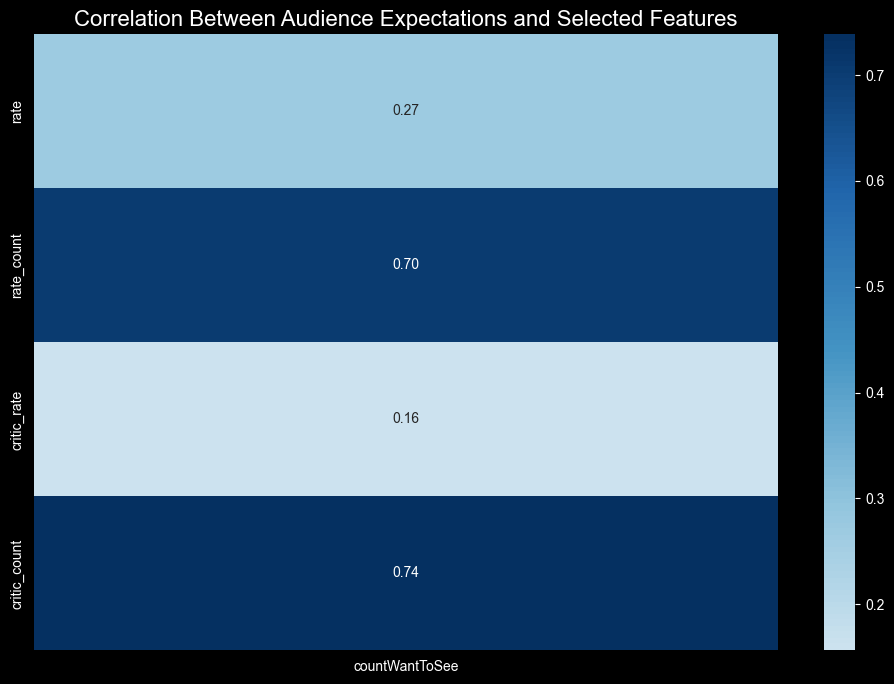

In [116]:
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu', fmt=".2f", center=0)

plt.title('Correlation Between Audience Expectations and Selected Features', fontsize=16)
plt.show()

The correlation shows that the more people are willing to watch a given film, the more ratings it will receive, which is completely natural. No significant correlations are observed between audience expectations and the final ratings.

### 3. Popularity Score - Top 10 most popular films

In [117]:
df_clean = df.dropna(subset=["rate_count", "critic_count"], how="any").copy()
print(f"Before: {df.shape[0]} -> After: {df_clean.shape[0]}")


Before: 732450 -> After: 40092


In [118]:
df_sort_by_fame = df_clean.sort_values(by=["rate_count", "rate"], ascending=False)
df_sort_by_fame[["originalTitle", "rate", "rate_count"]].head(10)

,originalTitle,rate,rate_count
556,The Green Mile,8.63245,1048255.0
678,Forrest Gump,8.55010,1037919.0
731,The Shawshank Redemption,8.80285,974350.0
325,The Matrix,7.59766,863973.0
364,Léon,8.14688,852423.0
6580,Shrek,7.82791,849805.0
160279,Avatar,7.38779,832305.0
619,Gladiator,8.14022,794824.0
188,Titanic,7.33578,792826.0
14875,Pirates of the Caribbean: The Curse of the Bla...,7.74429,743617.0
